# Credit Scoring - Exploratory Data Analysis

## Project objective

The goal of this project is to develop a machine learning model
for credit risk assessment.

## 1. Imports & configuration

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

sns.set_theme(style='whitegrid')

## 2. Data loading

The dataset contains information about borrowers and their credit
history.

The target variable is `SeriousDlqin2yrs`.

In [3]:
df = pd.read_csv('data/train.csv', index_col='Id')
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
Id,,,,,,,,,,,
1,0,0.957,40,0,0.122,2600.000,4,0,0,0,1.000
2,0,0.658,38,1,0.085,3042.000,2,1,0,0,0.000
3,0,0.234,30,0,0.036,3300.000,5,0,0,0,0.000
4,0,0.907,49,1,0.025,63588.000,7,0,1,0,0.000
5,0,0.213,74,0,0.376,3500.000,3,0,1,0,1.000


In [4]:
print(f'Dataset shape: {df.shape}')

Dataset shape: (104805, 11)


## 3. Dataset overview

This section provides a general overview of the dataset structure,
data types, missing values, duplicate observations and feature
cardinality.

In [5]:
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')

Rows: 104,805
Columns: 11


In [6]:
df.dtypes

SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

In [7]:
df.info()

<class 'pandas.DataFrame'>
Index: 104805 entries, 1 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      104805 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  104805 non-null  float64
 2   age                                   104805 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  104805 non-null  int64  
 4   DebtRatio                             104805 non-null  float64
 5   MonthlyIncome                         84024 non-null   float64
 6   NumberOfOpenCreditLinesAndLoans       104805 non-null  int64  
 7   NumberOfTimes90DaysLate               104805 non-null  int64  
 8   NumberRealEstateLoansOrLines          104805 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  104805 non-null  int64  
 10  NumberOfDependents                    102056 non-null  float64
dtypes: float64(4), i

In [8]:
missing = (
    df.isna()
      .sum()
      .to_frame('missing_count')
)

missing['missing_percent'] = (
    missing['missing_count']
    / len(df)
    * 100
)

missing = missing.sort_values(
    'missing_percent',
    ascending=False
)

missing

,missing_count,missing_percent
MonthlyIncome,20781,19.828
NumberOfDependents,2749,2.623
SeriousDlqin2yrs,0,0.000
age,0,0.000
RevolvingUtilizationOfUnsecuredLines,0,0.000
DebtRatio,0,0.000
NumberOfTime30-59DaysPastDueNotWorse,0,0.000
NumberOfOpenCreditLinesAndLoans,0,0.000
NumberOfTimes90DaysLate,0,0.000
NumberRealEstateLoansOrLines,0,0.000


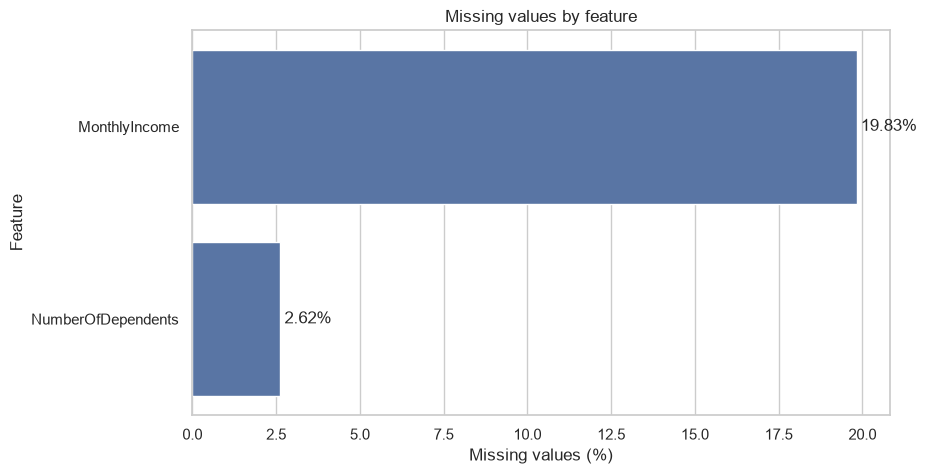

In [9]:
missing_plot = (
    missing[missing['missing_count'] > 0]
    .reset_index()
    .rename(columns={'index': 'feature'})
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=missing_plot,
    x='missing_percent',
    y='feature'
)

plt.title('Missing values by feature')
plt.xlabel('Missing values (%)')
plt.ylabel('Feature')

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f%%',
        padding=3
    )

plt.show()

### Duplicate observations

In [10]:
duplicate_count = df.duplicated().sum()

print(f'Duplicate rows: {duplicate_count:,}')

Duplicate rows: 353


### Conclusion

The dataset contains 353 duplicated feature rows.

These observations will not be removed at this stage.
We will investigate whether duplicated observations are associated
with different target values before making a preprocessing decision.

In [11]:
unique_values = (
    df.nunique()
    .sort_values()
    .to_frame('unique_values')
)

unique_values

,unique_values
SeriousDlqin2yrs,2
NumberOfTime60-89DaysPastDueNotWorse,12
NumberOfDependents,12
NumberOfTime30-59DaysPastDueNotWorse,15
NumberOfTimes90DaysLate,19
NumberRealEstateLoansOrLines,26
NumberOfOpenCreditLinesAndLoans,58
age,85
MonthlyIncome,12147
DebtRatio,82227


## 4. Target analysis

The target variable is `SeriousDlqin2yrs`.

- `0` — no serious delinquency within two years
- `1` — serious delinquency within two years

In [12]:
target_counts = df['SeriousDlqin2yrs'].value_counts()

target_summary = pd.DataFrame({
    'count': target_counts,
    'percentage': target_counts / len(df) * 100
})

target_summary

,count,percentage
SeriousDlqin2yrs,,
0,97855,93.369
1,6950,6.631


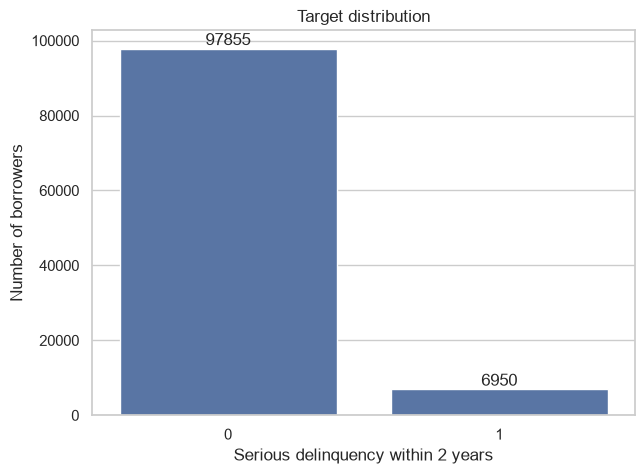

In [13]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x='SeriousDlqin2yrs'
)

plt.title('Target distribution')
plt.xlabel('Serious delinquency within 2 years')
plt.ylabel('Number of borrowers')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

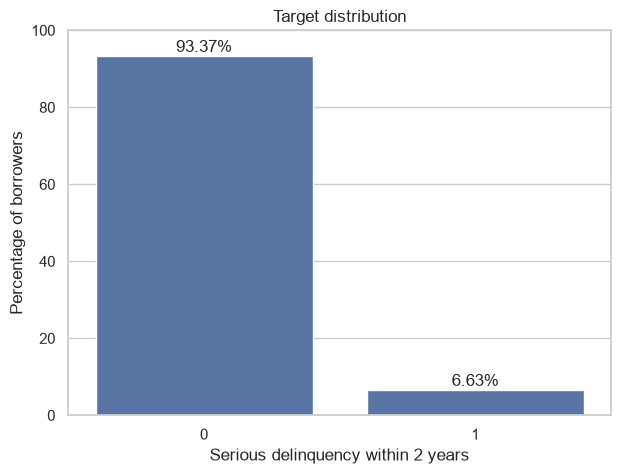

In [14]:
target_percent = (
    df['SeriousDlqin2yrs']
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=target_percent.index,
    y=target_percent.values
)

plt.title('Target distribution')
plt.xlabel('Serious delinquency within 2 years')
plt.ylabel('Percentage of borrowers')

for i, value in enumerate(target_percent.values):
    ax.text(
        i,
        value + 1,
        f'{value:.2f}%',
        ha='center'
    )

plt.ylim(0, 100)
plt.show()

### Conclusion

The target variable is strongly imbalanced.

Only approximately 6.63% of borrowers belong to the positive
class, while approximately 93.37% belong to the negative class.

Therefore, accuracy alone will not be an appropriate metric for
evaluating the final classification model.

ROC-AUC, PR-AUC, precision, recall and the confusion matrix will
be considered during model evaluation.

## 5. Feature analysis

The features are divided into continuous variables and count-based
variables to make their distributions easier to analyze.

In [15]:
continuous_features = [
    'RevolvingUtilizationOfUnsecuredLines',
    'DebtRatio',
    'MonthlyIncome'
]

In [16]:
count_features = [
    'age',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate',
    'NumberRealEstateLoansOrLines',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfDependents'
]

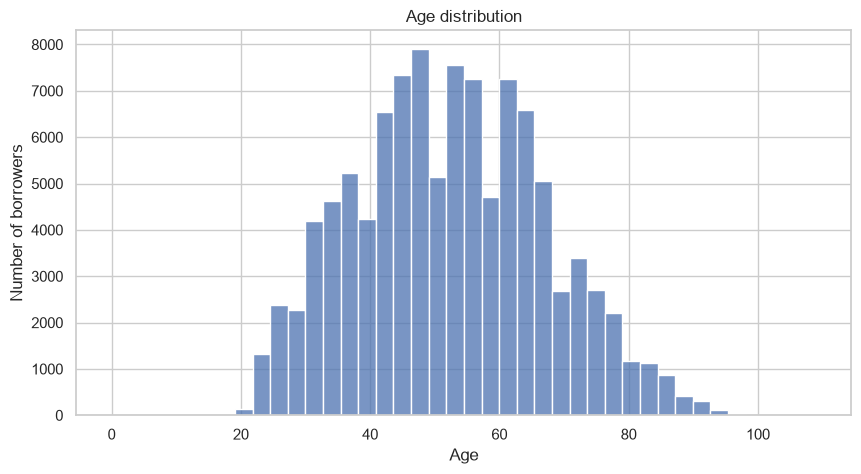

In [17]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='age',
    bins=40
)

plt.title('Age distribution')
plt.xlabel('Age')
plt.ylabel('Number of borrowers')

plt.show()

### Age distribution

The age distribution is concentrated around the middle-aged
borrower population. One observation has age 0, while 10
observations have age above 100.

The age value of 0 will be investigated as a potential data-quality
issue. Extreme ages above 100 will not be removed automatically.

## 6. Data quality investigation

### Suspicious delinquency values

In [18]:
late_payment_features = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

In [19]:
for feature in late_payment_features:
    count_98 = (df[feature] == 98).sum()

    print(f'{feature}: {count_98:,} observations with value 98')

NumberOfTime30-59DaysPastDueNotWorse: 181 observations with value 98
NumberOfTime60-89DaysPastDueNotWorse: 181 observations with value 98
NumberOfTimes90DaysLate: 181 observations with value 98


In [20]:
mask_98 = (
    df[late_payment_features]
    .eq(98)
    .all(axis=1)
)

target_rate = (
    df.assign(has_98=mask_98)
      .groupby('has_98')['SeriousDlqin2yrs']
      .mean()
      * 100
)

target_rate

has_98
False    6.552
True    52.486
Name: SeriousDlqin2yrs, dtype: float64

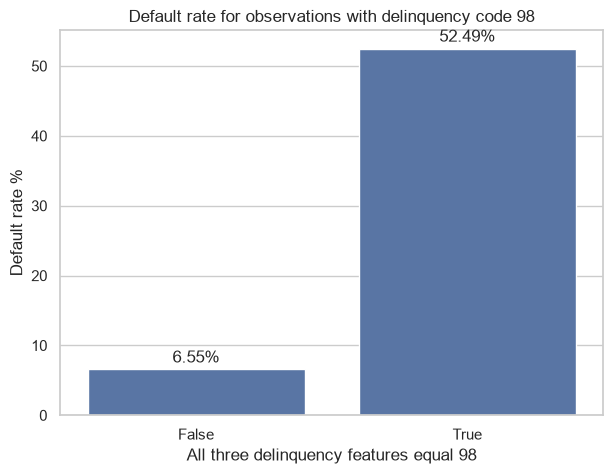

In [21]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=target_rate.index,
    y=target_rate.values
)

plt.title('Default rate for observations with delinquency code 98')
plt.xlabel('All three delinquency features equal 98')
plt.ylabel('Default rate %')

for i, value in enumerate(target_rate.values):
    ax.text(
        i,
        value + 1,
        f'{value:.2f}%',
        ha='center'
    )

plt.show()

## 7. Data quality investigation

This section investigates values that may represent data-quality
issues, special encodings or extreme observations.

In [22]:
print(f'Age < 18: {(df['age'] < 18).sum()}')
print(f'Age > 100: {(df['age'] > 100).sum()}')

Age < 18: 1
Age > 100: 10


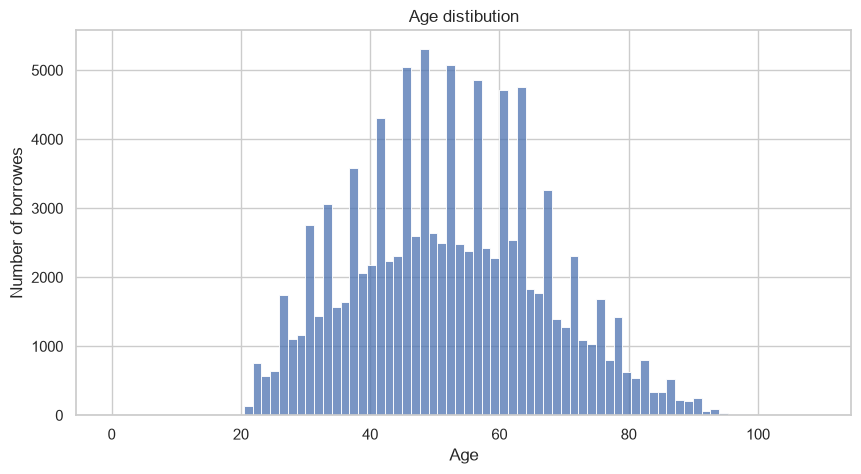

In [23]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='age',
    bins=80
)

plt.title('Age distibution')
plt.xlabel('Age')
plt.ylabel('Number of borrowes')

plt.show()

In [24]:
age_anomalies = df[
    (df['age'] < 18) |
    (df['age'] > 100)
]

age_anomalies[
    ['age', 'SeriousDlqin2yrs']
]

,age,SeriousDlqin2yrs
Id,,
7763,101,0
19884,103,0
25561,102,0
56761,105,0
57967,103,0
65695,0,0
90937,102,0
96450,102,0
116129,101,1


### 7.2 Special value 98

Three delinquency-related features contain the value `98`.

The value appears 181 times in each feature.

We investigate whether these observations form the same group and
whether the special value is associated with the target.

In [25]:
late_payment_features = [
   'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

In [26]:
for feature in late_payment_features:
    print(
        f'{feature}: ',
        f'{(df[feature] == 98).sum():,}'
    )

NumberOfTime30-59DaysPastDueNotWorse:  181
NumberOfTime60-89DaysPastDueNotWorse:  181
NumberOfTimes90DaysLate:  181


In [27]:
mask_98 = (
    df[late_payment_features]
    .eq(98)
    .all(axis=1)
)

print(f'Rows where all three features equal 98: {mask_98.sum():,}')

Rows where all three features equal 98: 181


In [28]:
target_rate_98 = df.loc[
    mask_98,
    'SeriousDlqin2yrs'
].mean()

target_rate_other = df.loc[
    ~mask_98,
    'SeriousDlqin2yrs'
].mean()

print(f'98 group:   {target_rate_98:.2%}')
print(f'Other rows: {target_rate_other:.2%}')

98 group:   52.49%
Other rows: 6.55%


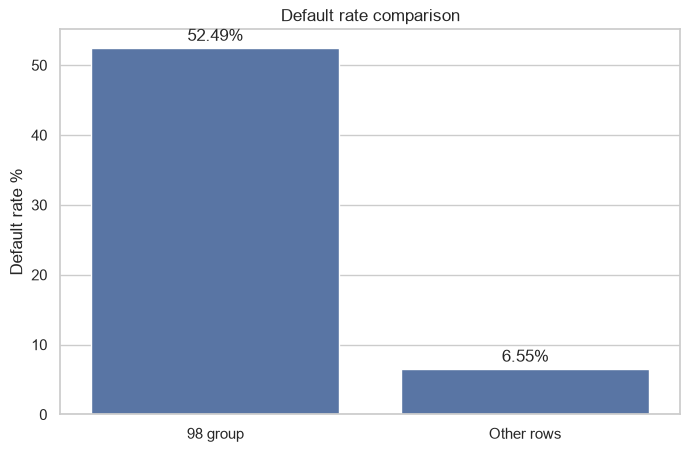

In [29]:
comparison = pd.Series({
    '98 group': target_rate_98 * 100,
    'Other rows': target_rate_other * 100
})

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=comparison.index,
    y=comparison.values
)

plt.title('Default rate comparison')
plt.xlabel('')
plt.ylabel('Default rate %')

for i, value in enumerate(comparison.values):
    ax.text(
        i, value + 1,
        f'{value:.2f}%',
        ha='center'
    )

plt.show()

### Conclusion

The three delinquency-related features contain the value `98`
in the same 181 observations.

These observations have a substantially higher positive-target
rate than the rest of the dataset.

### 7.3 Revolving utilization

`RevolvingUtilizationOfUnsecuredLines` shows a highly skewed
distribution with extreme values.

In [30]:
feature = 'RevolvingUtilizationOfUnsecuredLines'

print(df[feature].describe())

print(
    f'\nValues > 1: '
    f'{(df[feature] > 1).sum():,}'
)

count   104805.000
mean         5.602
std        217.390
min          0.000
25%          0.030
50%          0.154
75%          0.559
max      29110.000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

Values > 1: 2,337


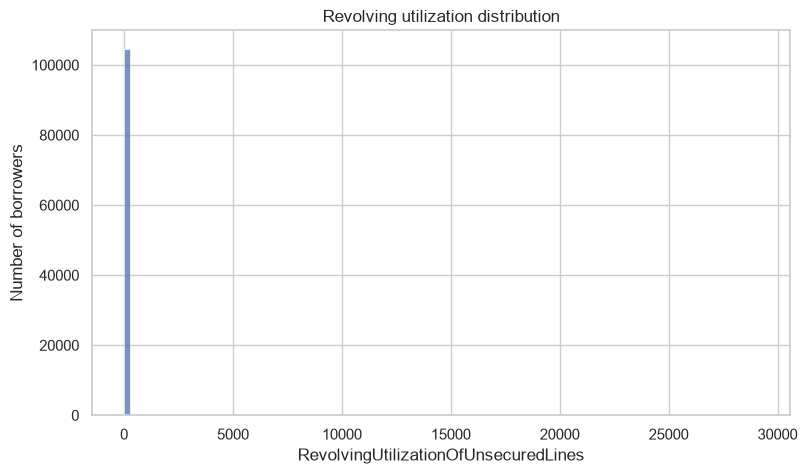

In [31]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x=feature,
    bins=100
)

plt.title('Revolving utilization distribution')
plt.xlabel(feature)
plt.ylabel('Number of borrowers')

plt.show()

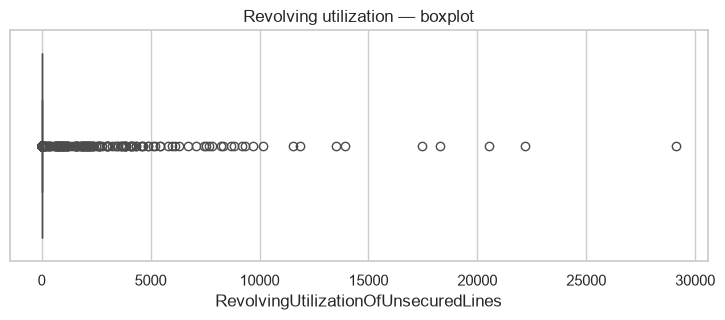

In [32]:
plt.figure(figsize=(9, 3))

sns.boxplot(
    data=df,
    x=feature
)

plt.title('Revolving utilization - boxplot')
plt.xlabel(feature)

plt.show()

### 7.4 Debt ratio

In [33]:
feature = 'DebtRatio'

print(df[feature].describe())

print(
    f'\nValues > 1: '
    f'{(df[feature] > 1).sum():,}'
)

count   104805.000
mean       354.859
std       2169.183
min          0.000
25%          0.175
50%          0.367
75%          0.867
max     329664.000
Name: DebtRatio, dtype: float64

Values > 1: 24,549


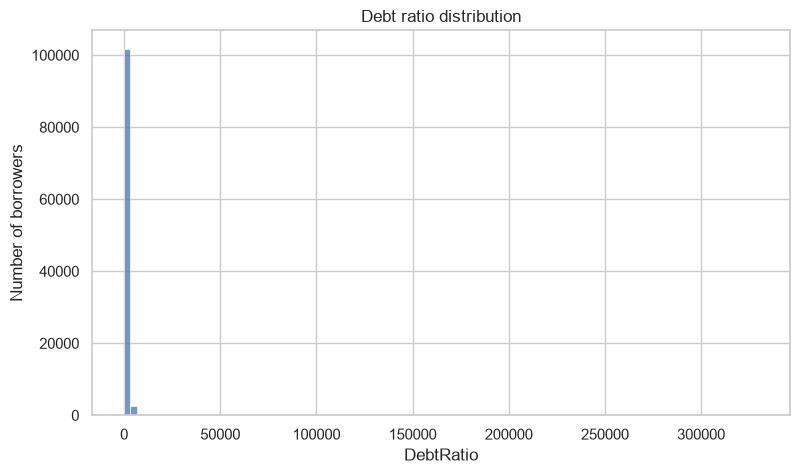

In [34]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x=feature,
    bins=100
)

plt.title('Debt ratio distribution')
plt.xlabel(feature)
plt.ylabel('Number of borrowers')

plt.show()

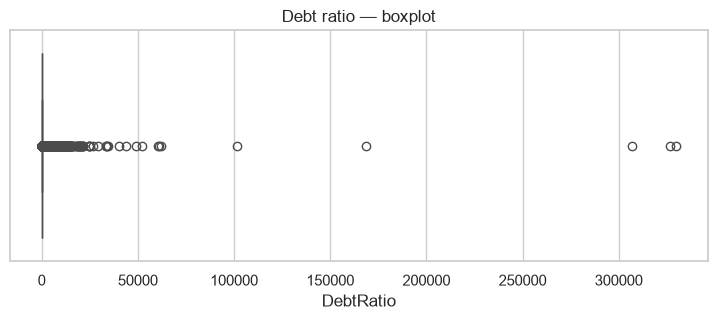

In [35]:
plt.figure(figsize=(9, 3))

sns.boxplot(
    data=df,
    x=feature
)

plt.title('Debt ratio - boxplot')
plt.xlabel(feature)

plt.show()

### 7.5 Monthly income

In [36]:
feature = 'MonthlyIncome'

print(df[feature].describe())

print(
    f'\nMissing values: '
    f'{df[feature].isna().sum():,}'
)

count     84024.000
mean       6684.453
std       15653.133
min           0.000
25%        3400.000
50%        5400.000
75%        8250.000
max     3008750.000
Name: MonthlyIncome, dtype: float64

Missing values: 20,781


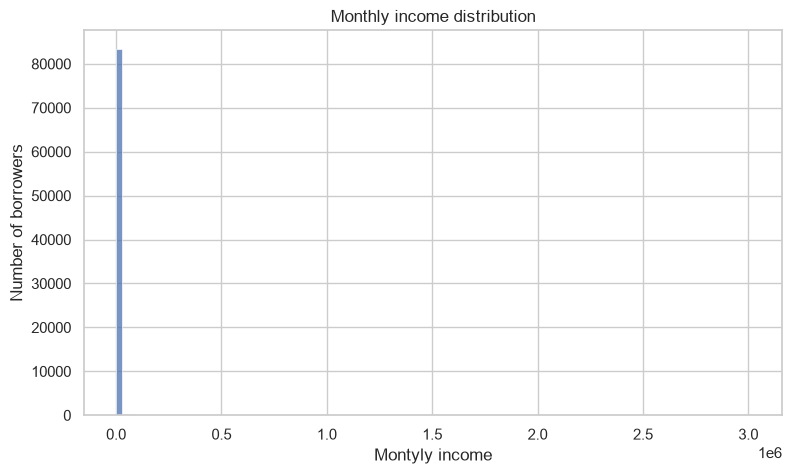

In [37]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x=feature,
    bins=100
)

plt.title('Monthly income distribution')
plt.xlabel('Montyly income')
plt.ylabel('Number of borrowers')

plt.show()

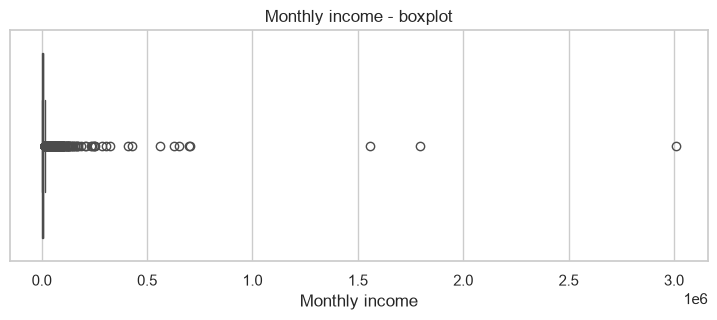

In [38]:
plt.figure(figsize=(9, 3))

sns.boxplot(
    data=df,
    x=feature
)

plt.title('Monthly income - boxplot')
plt.xlabel('Monthly income')

plt.show()

## 8. Feature vs target

This section investigates how borrower characteristics are
associated with the target variable.

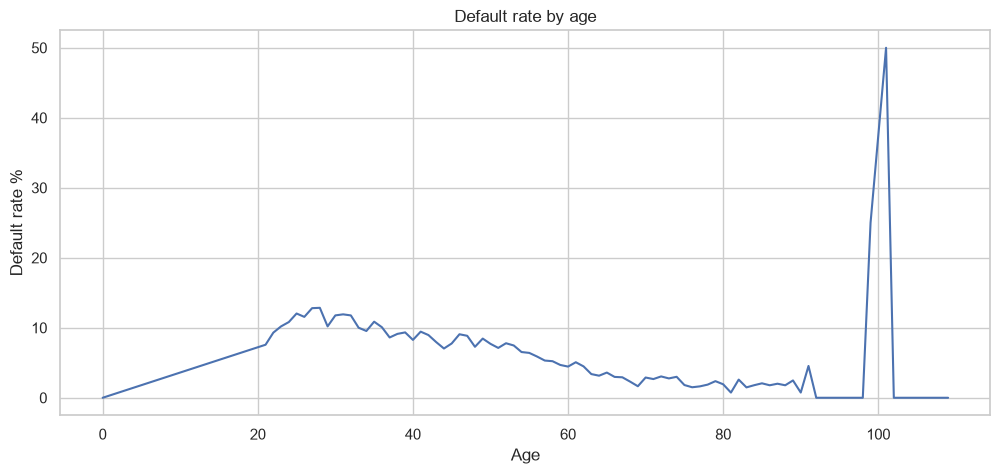

In [39]:
age_default_rate = (
    df.groupby('age')['SeriousDlqin2yrs'].mean() * 100
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    x=age_default_rate.index,
    y=age_default_rate.values
)

plt.title('Default rate by age')
plt.xlabel('Age')
plt.ylabel('Default rate %')

plt.show()

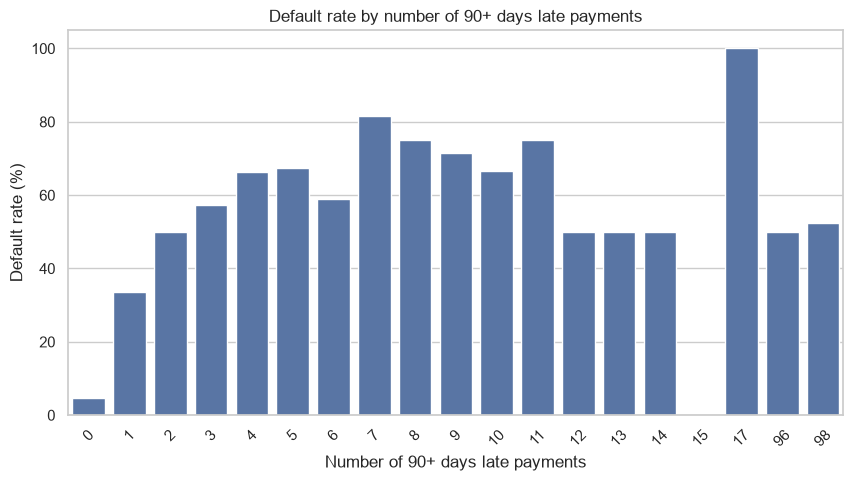

In [40]:
feature = "NumberOfTimes90DaysLate"

default_rate = (
    df.groupby(feature)["SeriousDlqin2yrs"]
    .mean()
    * 100
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=default_rate.index,
    y=default_rate.values
)

plt.title("Default rate by number of 90+ days late payments")
plt.xlabel("Number of 90+ days late payments")
plt.ylabel("Default rate (%)")

plt.xticks(rotation=45)

plt.show()

## 9. Correlation analysis

Correlation analysis is used to understand linear relationships
between numerical variables.

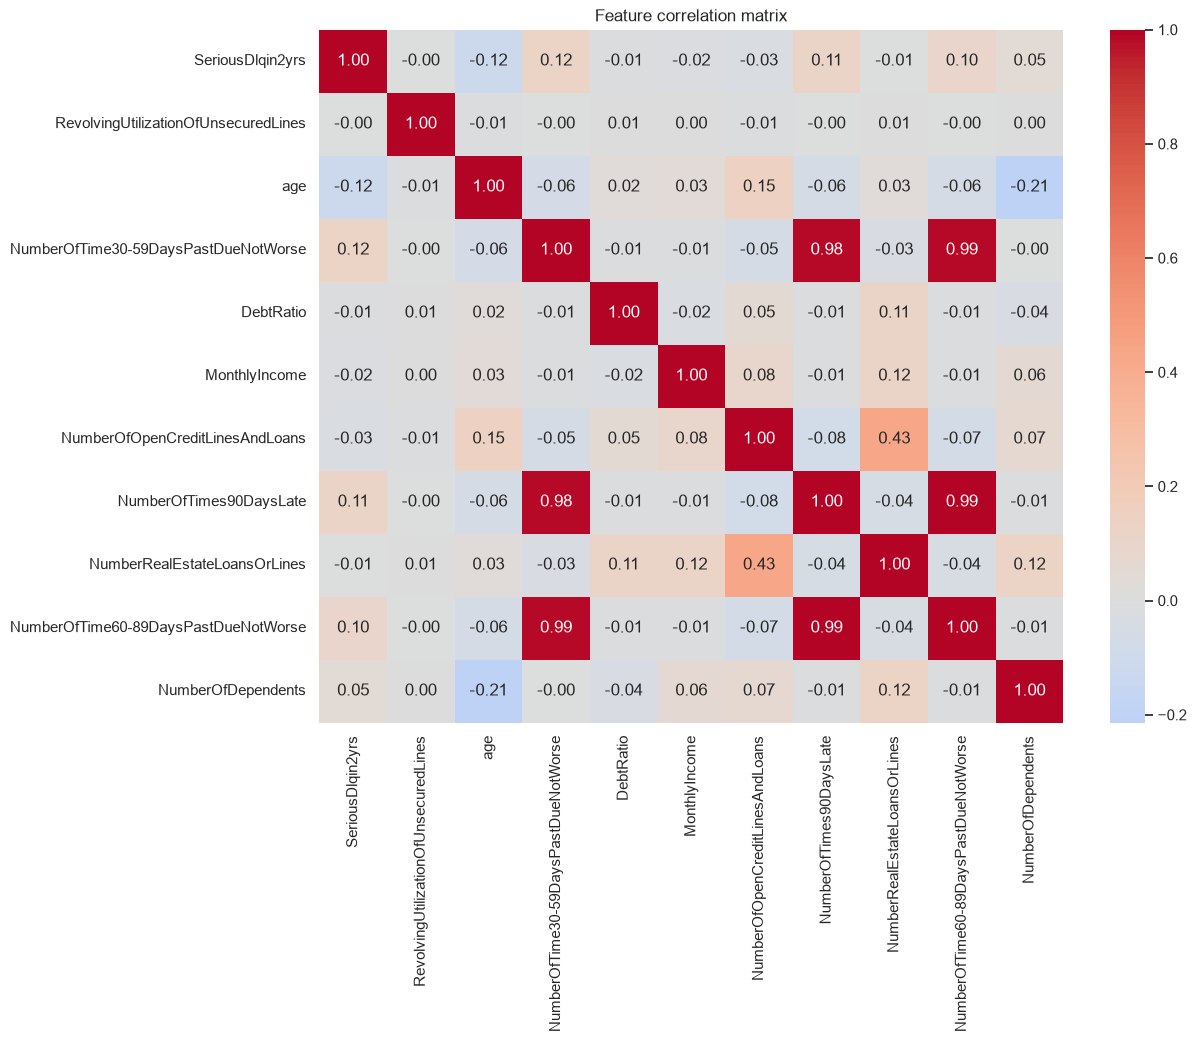

In [41]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Feature correlation matrix')

plt.show()

## 10. EDA conclusions

### Dataset

- The dataset contains 104,805 observations and 11 columns.
- The target variable is `SeriousDlqin2yrs`.
- The dataset contains 353 duplicate rows.

### Missing values

- `MonthlyIncome` contains 20,781 missing values.
- `NumberOfDependents` contains 2,749 missing values.

### Target

- The target is strongly imbalanced.
- The positive class represents approximately 6.63% of observations.

### Data quality

- One observation has an age below 18.
- Ten observations have an age above 100.
- Three delinquency features contain the special value `98`
  in the same 181 observations.
- The `98` group has a substantially higher positive-target rate
  than the rest of the dataset.
- `RevolvingUtilizationOfUnsecuredLines`, `DebtRatio` and
  `MonthlyIncome` contain highly skewed distributions and extreme
  values.
